Cargando y limpiando datos...

Iniciando la cacería del hiperparámetro C con LinearSVC...
C=0.01  | Train: 0.6130 | Val: 0.2240
C=0.1   | Train: 0.9289 | Val: 0.2635
C=0.2   | Train: 0.9763 | Val: 0.2686
C=0.3   | Train: 0.9889 | Val: 0.2700
C=0.5   | Train: 0.9967 | Val: 0.2713
C=0.7   | Train: 0.9984 | Val: 0.2681


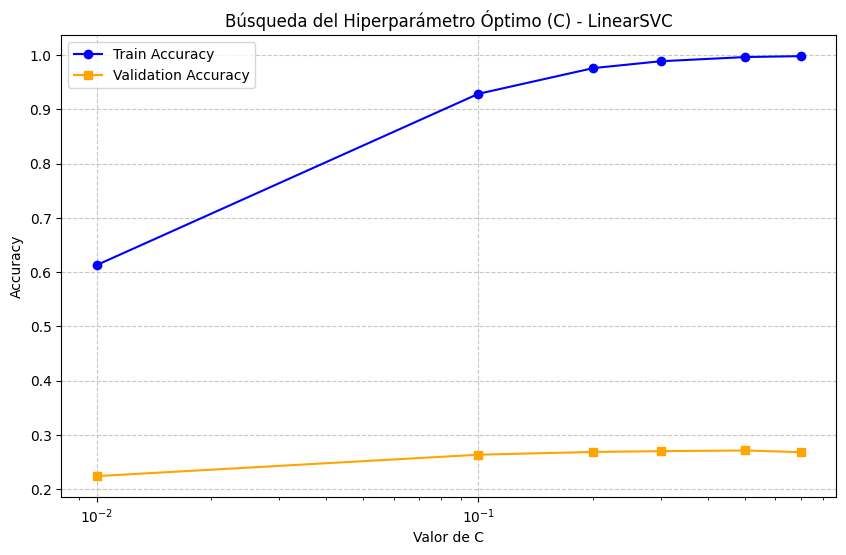

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline

from sklearn.svm import LinearSVC 

def cleant_text_no_simbols(texto):
    if not isinstance(texto, str):
        return ""

    texto = texto.lower()
    texto = texto.replace('ñ', 'n')
    texto = re.sub(r'[-¬]\s*', '', texto)
    texto = re.sub(r'[^a-z0-9áéíóúüñ¡!¿?.,;():«»—+ſꝛũ’\s]', ' ', texto)    
    #texto = re.sub(r'\s+', ' ', texto).strip()

    return texto


# --- 1. LECTURA Y LIMPIEZA ---
print("Cargando y limpiando datos...")
data = pd.read_csv("../../data/train.csv")
data_test = pd.read_csv("../../data/eval.csv")

col_text_clean = "text_clean"

data[col_text_clean] = data['text'].apply(cleant_text_no_simbols)
data_test[col_text_clean] = data_test['text'].apply(cleant_text_no_simbols)

data_X = data[col_text_clean]
data_y = data["decade"]

X_train, X_val, y_train, y_val = train_test_split(
    data_X, data_y, test_size=0.2, random_state=42, stratify=data_y
)

# --- 2. BÚSQUEDA DEL HIPERPARÁMETRO ---
print("\nIniciando la cacería del hiperparámetro C con LinearSVC...")
valores_C = [0.01, 0.1, 0.2, 0.3, 0.5, 0.7]
historia_train = []
historia_val = []

for c in valores_C:
    modelo_prueba = make_pipeline(
        TfidfVectorizer(
            analyzer='char_wb',
            ngram_range=(2, 4),
            max_df=0.85,
            min_df=2,            
            max_features=150000, 
            lowercase=False,
            sublinear_tf=True
        ),
        
        LinearSVC(
            C=c,
            class_weight='balanced',
            random_state=42,
            max_iter=5000,
            dual=False 
        )
    )
    
    modelo_prueba.fit(X_train, y_train)
    acc_train = accuracy_score(y_train, modelo_prueba.predict(X_train))
    acc_val = accuracy_score(y_val, modelo_prueba.predict(X_val))
    
    historia_train.append(acc_train)
    historia_val.append(acc_val)
    
    print(f"C={c:<5} | Train: {acc_train:.4f} | Val: {acc_val:.4f}")

# --- 3. GRAFICAMOS LOS RESULTADOS ---
plt.figure(figsize=(10, 6))
plt.plot(valores_C, historia_train, marker='o', linestyle='-', color='blue', label='Train Accuracy')
plt.plot(valores_C, historia_val, marker='s', linestyle='-', color='orange', label='Validation Accuracy')
plt.title("Búsqueda del Hiperparámetro Óptimo (C) - LinearSVC")
plt.xlabel("Valor de C")
plt.ylabel("Accuracy")
plt.xscale('log') # Escala logarítmica para ver bien los valores bajos como 0.1
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [2]:
# --- 3. CONSTRUCCIÓN DEL MODELO FINAL ---
# OJO: Cuando veas la gráfica, actualiza este valor de C por el que haya dado el punto más alto en validación.
MEJOR_C = 0.5

modelo_texto = make_pipeline(
    TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(2, 4),
        max_df=0.85,
        min_df=2,            
        max_features=150000, 
        lowercase=False,
        sublinear_tf=True
    ),
    
    # ¡AQUÍ ESTÁ LA MAGIA DEL NUEVO MODELO!
    LinearSVC(
        C=MEJOR_C,
        class_weight='balanced',
        random_state=42,
        max_iter=5000,
        dual=False # Se recomienda en False cuando generamos muchas features (150k) para evitar advertencias
    )
)

modelo_texto.fit(X_train, y_train)

print(f"\n=== DIAGNÓSTICO DEL MODELO FINAEL (C={MEJOR_C}) ===")
print(f"Accuracy Train: {accuracy_score(y_train, modelo_texto.predict(X_train)):.4f}")
print(f"Accuracy Val:   {accuracy_score(y_val, modelo_texto.predict(X_val)):.4f}")

# --- 4. RETRENAMIENTO Y EXPORTACIÓN KAGGLE ---
print("\nRetrenando con el 100% de los datos para el envío final...")
modelo_texto.fit(data_X, data_y) 

predictions_test = modelo_texto.predict(data_test[col_text_clean])

df_envio = pd.DataFrame({
    'id': data_test['id'],
    'answer': predictions_test
})

df_envio.to_csv("lineal.csv", index=False)
print("¡Archivo answer.csv generado con éxito!")


=== DIAGNÓSTICO DEL MODELO FINAEL (C=0.5) ===
Accuracy Train: 0.9967
Accuracy Val:   0.2713

Retrenando con el 100% de los datos para el envío final...
¡Archivo answer.csv generado con éxito!
